# Demo 2
## Controlled Pendulum
### FMPy Co-Simulation

**Modelica Models**

In [1]:
from path import Path

root = Path(r'/home/flo/repos/SystemSimulation/demos/ControlledPendulum/')
pkg_dir = Path(root / "ControlledPendulum")
pkg_str = str(root / "ControlledPendulum" / "package.mo")
pkg_name = "ControlledPendulum"

model_names = Path(pkg_dir).files("*.mo")
model_names = [m.stem for m in model_names if m.stem != "package"]

for model_name in model_names:
    print(f"Found model: {model_name}")

Found model: PID_Cont
Found model: PIDController
Found model: DemoModel
Found model: Drive
Found model: Pendulum
Found model: ReferenceTrajectory
Found model: Sensor


**Helper Functions for FMU Creation**

In [2]:
from OMPython import ModelicaSystem
import shutil

def create_modelica_system(model_name):
    model = ModelicaSystem(pkg_str, model_name, verbose=True)
    return model

def create_fmu(model: ModelicaSystem, fmuType="cs"):
    model.buildModel()
    fmu_path = model.convertMo2Fmu(fmuType=fmuType)
    return fmu_path

def move_file(src_path, dst_path):
    shutil.move(src_path, dst_path)

**Create FMUs for the Models**

In [3]:
fmu_path_dict = {}
num_models = len(model_names)
for model_name, i in zip(model_names, range(len(model_names))):
    print(60 * "-")
    print(f"Creating FMU {i + 1}/{num_models}: {model_name}")
    
    # Create Modelica model
    model = create_modelica_system(pkg_name + "." + model_name)
    
    # Create FMU
    fmu_path = create_fmu(model)
    
    # Define destination path and move FMU there
    dest_path = str(root / "FMUs" / (model_name + ".fmu"))
    
    # Move FMU to destination path
    move_file(fmu_path, dest_path)

    # Add to dictionary
    fmu_path_dict[model_name] = dest_path

------------------------------------------------------------
Creating FMU 1/7: PID_Cont

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


------------------------------------------------------------
Creating FMU 2/7: PIDController

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


------------------------------------------------------------
Creating FMU 3/7: DemoModel

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotati

In [4]:
# Import FMPy
from fmpy import read_model_description

fmu_dict = {}

# Read model descriptions and variable references
for model_name, fmu_path in fmu_path_dict.items():
    fmu_dict[model_name] = {}
    fmu_dict[model_name]["ModelDescription"] = read_model_description(fmu_path)
    vrs = {}
    for variable in fmu_dict[model_name]["ModelDescription"].modelVariables:
        vrs[variable.name] = variable.valueReference
    fmu_dict[model_name]["VariableReferences"] = vrs
    print(60 * "-")
    print(f"Loaded FMU: {model_name}:.")
    print(f"  Variables: {list(vrs.keys())}")
    print(f"  Variable References: {list(vrs.values())}")
    

------------------------------------------------------------
Loaded FMU: PID_Cont:.
  Variables: ['D.x', 'I.y', 'der(D.x)', 'der(I.y)', 'der(_D_outputAlias_u)', 'ref', 'u', 'y', 'Nd', 'Td', 'Ti', 'k', 'uMax', 'uMin', 'xd_start', 'xi_start']
  Variable References: [0, 1, 2, 3, 4, 17, 19, 20, 27, 29, 30, 34, 40, 41, 42, 43]
------------------------------------------------------------
Loaded FMU: PIDController:.
  Variables: ['der(_D_outputAlias_u_control)', 'reference', 'state', 'u_control', 'Kd', 'Ki', 'Kp', 'dt', 'uMax', 'uMin']
  Variable References: [0, 3, 4, 5, 15, 16, 17, 18, 19, 20]
------------------------------------------------------------
Loaded FMU: DemoModel:.
  Variables: ['drive.I', 'pendulum.omega', 'pendulum.q', 'pid.D.x', 'pid.I.y', 'der(drive.I)', 'der(pendulum.omega)', 'der(pendulum.q)', 'der(pid.D.x)', 'der(pid.I.y)', '_D_TMP_D_VAR_D_41_D_0INV_D_SIN', '_D_TMP_D_VAR_D_41_D_0PREX_D_SIN', '_D_TMP_D_VAR_D_41_D_0Y_D_SIN', '_D_TMP_D_VAR_D_41_D_0k1_D_SIN', '_D_TMP_D_VAR_D_4

In [94]:
from fmpy import extract
from fmpy.fmi2 import FMU2Slave

# Instantiate Reference Trajectory
unzip_dir = extract(fmu_path_dict['ReferenceTrajectory'])
ref_fmu = FMU2Slave(guid=fmu_dict['ReferenceTrajectory']["ModelDescription"].guid,
                    unzipDirectory=unzip_dir,
                    modelIdentifier=fmu_dict['ReferenceTrajectory']["ModelDescription"].coSimulation.modelIdentifier,
                    instanceName='ref_fmu')
ref_fmu.instantiate()

# Instantiate Pendulum
unzip_dir = extract(fmu_path_dict['Pendulum'])
pendulum_fmu = FMU2Slave(guid=fmu_dict['Pendulum']["ModelDescription"].guid,
                          unzipDirectory=unzip_dir,
                          modelIdentifier=fmu_dict['Pendulum']["ModelDescription"].coSimulation.modelIdentifier,
                          instanceName='pendulum_fmu')
pendulum_fmu.instantiate()

# Instantiate Sensors for Reference Trajectory and Pendulum
unzip_dir = extract(fmu_path_dict['Sensor'])
sensor_ref_fmu = FMU2Slave(guid=fmu_dict['Sensor']["ModelDescription"].guid,
                         unzipDirectory=unzip_dir,
                         modelIdentifier=fmu_dict['Sensor']["ModelDescription"].coSimulation.modelIdentifier,
                         instanceName='sensor_ref_fmu')
sensor_ref_fmu.instantiate()

sensor_state_fmu = FMU2Slave(guid=fmu_dict['Sensor']["ModelDescription"].guid,
                         unzipDirectory=unzip_dir,
                         modelIdentifier=fmu_dict['Sensor']["ModelDescription"].coSimulation.modelIdentifier,
                         instanceName='sensor_state_fmu')
sensor_state_fmu.instantiate()

# Instantiate Controller
unzip_dir = extract(fmu_path_dict['PID_Cont'])
pid_fmu = FMU2Slave(guid=fmu_dict['PID_Cont']["ModelDescription"].guid,
                    unzipDirectory=unzip_dir,
                    modelIdentifier=fmu_dict['PID_Cont']["ModelDescription"].coSimulation.modelIdentifier,
                    instanceName='pid_fmu')
pid_fmu.instantiate()

# Instantiate Drive
unzip_dir = extract(fmu_path_dict['Drive'])
drive = FMU2Slave(guid=fmu_dict['Drive']["ModelDescription"].guid,
                  unzipDirectory=unzip_dir,
                  modelIdentifier=fmu_dict['Drive']["ModelDescription"].coSimulation.modelIdentifier,
                  instanceName='drive')
drive.instantiate()

fmu_list = [ref_fmu, pendulum_fmu, sensor_ref_fmu, sensor_state_fmu, pid_fmu, drive]

In [95]:
t = 0.0
tf = 10.0
h = 0.001

for fmu in fmu_list:
    fmu.reset()
    fmu.setupExperiment(startTime=t)
    fmu.enterInitializationMode()
    fmu.exitInitializationMode()

# Initialize logging arrays
ts = []
q_ref_log, q_state_log, omega_state_log = [], [], []
U_ref_log, U_state_log = [], []

In [96]:
vars = {}
vars['q_ref'] = fmu_dict['ReferenceTrajectory']['VariableReferences']['q_ref']

vars['q_state'] = fmu_dict['Pendulum']['VariableReferences']['q_state']
vars['omega_state'] = fmu_dict['Pendulum']['VariableReferences']['omega_state']
vars['torque'] = fmu_dict['Pendulum']['VariableReferences']['torque']

vars['q_sensor'] = fmu_dict['Sensor']['VariableReferences']['q']
vars['U_q'] = fmu_dict['Sensor']['VariableReferences']['U_q']

vars['pid_y'] = fmu_dict['PID_Cont']['VariableReferences']['y']
vars['pid_ref'] = fmu_dict['PID_Cont']['VariableReferences']['ref']
vars['pid_u'] = fmu_dict['PID_Cont']['VariableReferences']['u']

vars['drive_u'] = fmu_dict['Drive']['VariableReferences']['u_control']
vars['drive_omega'] = fmu_dict['Drive']['VariableReferences']['omega']
vars['drive_torque'] = fmu_dict['Drive']['VariableReferences']['torque']

In [97]:
sensor_ref_fmu.setReal([fmu_dict['Sensor']['VariableReferences']['q']], [0.01])
sensor_state_fmu.setReal([fmu_dict['Sensor']['VariableReferences']['q']], [0.0])

sensor_ref_fmu.doStep(currentCommunicationPoint=t, communicationStepSize=h)
sensor_state_fmu.doStep(currentCommunicationPoint=t, communicationStepSize=h)

U_q_ref = sensor_ref_fmu.getReal([vars['U_q']])[0]
U_q_state = sensor_state_fmu.getReal([vars['U_q']])[0]

print(60 * "-")
print('U_q_ref:', U_q_ref)
print('U_q_state:', U_q_state)

------------------------------------------------------------
U_q_ref: 1.5058823529411764
U_q_state: 1.4941176470588236


In [98]:
pid_fmu.setReal([vars['pid_y'], vars['pid_ref']], [U_q_state, U_q_ref])
pid_fmu.doStep(currentCommunicationPoint=t, communicationStepSize=h)
u_pid = pid_fmu.getReal([vars['pid_u']])[0]

print('u_pid:', u_pid)

u_pid: 0.1176705882352937


In [99]:
drive.setReal([vars['drive_u']], [u_pid])
drive.doStep(currentCommunicationPoint=t, communicationStepSize=h)
torque = drive.getReal([vars['drive_torque']])[0]
print('torque:', torque)

torque: 23.80641322314041


In [100]:
pendulum_fmu.setReal([vars['torque']], [torque])
pendulum_fmu.doStep(currentCommunicationPoint=t, communicationStepSize=h)
q_state = pendulum_fmu.getReal([vars['q_state']])[0]
omega_state = pendulum_fmu.getReal([vars['omega_state']])[0]
print('q_state:', q_state)
print('omega_state:', omega_state)

q_state: 0.0
omega_state: 0.009299380165289221


In [101]:
while t < tf:
    # 1) Read the current reference position
    ref_fmu.doStep(t, h)
    q_ref = ref_fmu.getReal([vars['q_ref']])
    
    # 2) Read the plant state at the current time
    q_state = pendulum_fmu.getReal([vars['q_state']])
    omega_state = pendulum_fmu.getReal([vars['omega_state']])

    # 3) Sensors: set inputs -> step -> read outputs
    sensor_ref_fmu.setReal([vars['q_sensor']], q_ref)
    sensor_state_fmu.setReal([vars['q_sensor']], q_state)
    sensor_ref_fmu.doStep(t, h)
    sensor_state_fmu.doStep(t, h)
    U_q_ref = sensor_ref_fmu.getReal([vars['U_q']])
    U_q_state = sensor_state_fmu.getReal([vars['U_q']])

    # 4) Controller: set inputs -> step -> read outputs
    pid_fmu.setReal([vars['pid_y'], vars['pid_ref']],
                    [U_q_state[0], U_q_ref[0]])
    pid_fmu.doStep(currentCommunicationPoint=t, communicationStepSize=h)
    u_pid = pid_fmu.getReal([vars['pid_u']])

    # 5) Drive: set inputs -> step -> read outputs
    drive.setReal([vars['drive_u'], vars['drive_omega']],
                  [u_pid[0], omega_state[0]])
    drive.doStep(currentCommunicationPoint=t, communicationStepSize=h)
    torque = drive.getReal([vars['drive_torque']])
    
    # 6) Plant: set inputs -> step
    pendulum_fmu.setReal([vars['torque']], torque)
    pendulum_fmu.doStep(currentCommunicationPoint=t, communicationStepSize=h)

    # Log data
    ts.append(t)
    q_ref_log.append(q_ref[0])
    q_state_log.append(q_state[0])
    omega_state_log.append(omega_state[0])
    U_ref_log.append(U_q_ref[0])
    U_state_log.append(U_q_state[0])
    
    # Advance time
    t += h

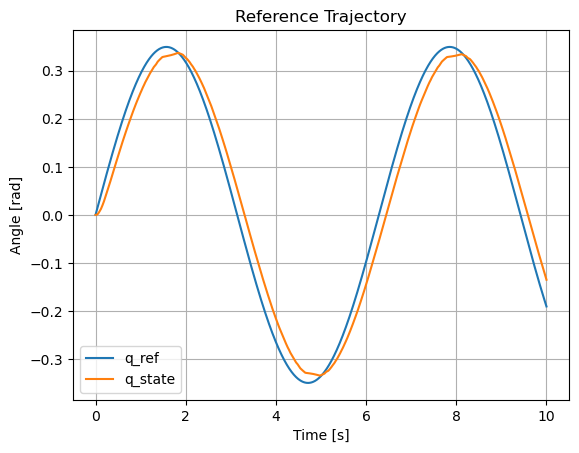

In [93]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(ts, q_ref_log, label="q_ref")
plt.plot(ts, q_state_log, label="q_state")
plt.xlabel("Time [s]")
plt.ylabel("Angle [rad]")
plt.title("Reference Trajectory")
plt.legend()
plt.grid()
plt.show()